***** UNIT 4 CODE *****

The goal of this code is to evaluate review sentiment and assess how it complements numerical ratings.

In [37]:
path = '/content/drive/My Drive/CIS617_TextAnalytics/TextAnalyticsCode_FordKCAP'

import pandas as pd
reviews_df = pd.read_csv(path+'/reviews.csv')
reviews_df.head(3)

,review_position,link,rating,date,iso_date,iso_date_of_last_edit,source,review_id,user,snippet,extracted_snippet,likes,images
0,1,https://www.google.com/maps/reviews/data=!4m8!...,5.0,5 months ago,2025-10-29T03:17:23Z,2025-10-29T03:17:23Z,Google,Ci9DQUlRQUNvZENodHljRjlvT214UlZHNXlhbXBUWjI1Rl...,"{'name': 'Sarah Tasciotti', 'link': 'https://w...",Easy drop and hook. Never had a problem with s...,"{'original': ""Easy drop and hook. Never had a ...",0,NaN
1,2,https://www.google.com/maps/reviews/data=!4m8!...,1.0,3 months ago,2025-12-28T14:33:40Z,2025-12-28T14:33:40Z,Google,Ci9DQUlRQUNvZENodHljRjlvT25rMFMxRjBSbWxWY213ek...,"{'name': 'Kaden Ash Richardson', 'link': 'http...",You make living across from you hell. Constant...,{'original': 'You make living across from you ...,0,NaN
2,3,https://www.google.com/maps/reviews/data=!4m8!...,1.0,Edited 5 months ago,2025-10-02T11:39:10Z,2025-10-10T14:14:55Z,Google,Ci9DQUlRQUNvZENodHljRjlvT2pCaGFGUlBNMnR1UXpsdV...,"{'name': 'T Gold', 'link': 'https://www.google...",Trucker beware... Mostly everyone is helpful e...,"{'original': ""Trucker beware... Mostly everyon...",0,NaN


In [38]:
!pip install nltk textblob

In [39]:
import nltk
import numpy as np
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd

nltk.download('vader_lexicon')
sid = SentimentIntensityAnalyzer()



[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [40]:
def sentiment(review):

  if(type(review) != str):
    return [np.nan,np.nan,np.nan,np.nan]

  sentiment_score = sid.polarity_scores(review)
  return [sentiment_score['neg'],sentiment_score['neu'],sentiment_score['pos'],sentiment_score['compound']]

reviews_df[['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound']] = reviews_df['snippet'].apply(sentiment).apply(pd.Series)


In [41]:
reviews_df[['sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound']].describe()

,sentiment_neg,sentiment_neu,sentiment_pos,sentiment_compound
count,198.000000,198.000000,198.000000,198.000000
mean,0.137348,0.755167,0.107500,-0.116042
std,0.124302,0.137915,0.119406,0.582955
min,0.000000,0.407000,0.000000,-0.966300
25%,0.000000,0.658000,0.000000,-0.612400
50%,0.114000,0.758500,0.074000,-0.150150
75%,0.218750,0.841750,0.184500,0.440400
max,0.565000,1.000000,0.593000,0.981900


The average sentiment scores suggest that most reviews are largely neutral in tone, as reflected by the high neutral sentiment mean of 0.755. This implies that many customers tend to describe their experiences in a straightforward, factual manner rather than expressing strong emotions. However, when opinions are expressed, negative sentiment (mean = 0.137) occurs slightly more often than positive sentiment (mean = 0.108). This imbalance results in a negative overall compound sentiment score of -0.116, indicating that, despite the dominance of neutral language, the general tone of the reviews leans slightly toward the negative.

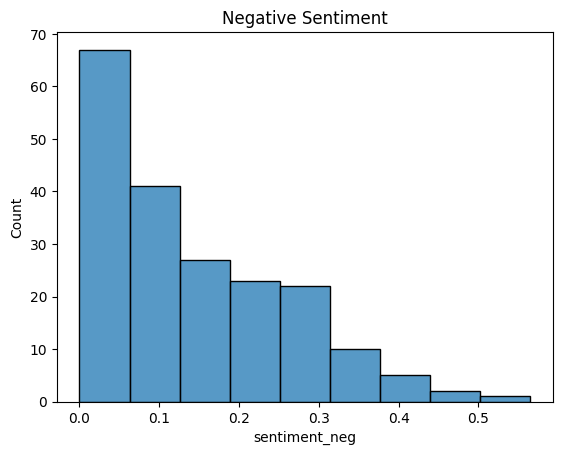

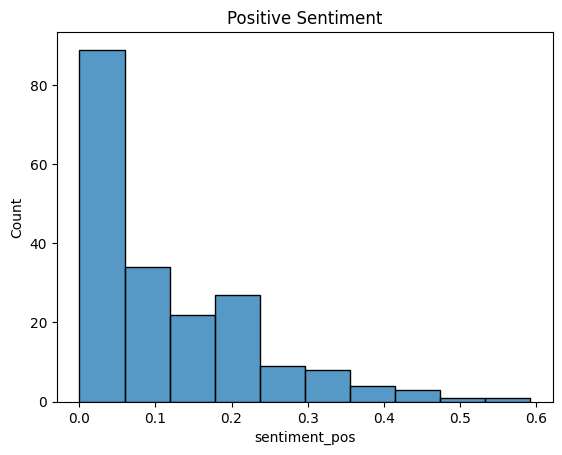

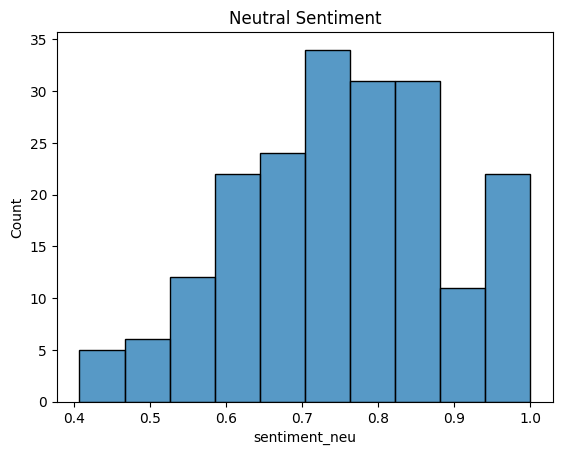

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.histplot(reviews_df['sentiment_neg'])
ax.set_title('Negative Sentiment')
plt.show()

ax = sns.histplot(reviews_df['sentiment_pos'])
ax.set_title('Positive Sentiment')
plt.show()

ax = sns.histplot(reviews_df['sentiment_neu'])
ax.set_title('Neutral Sentiment')
plt.show()

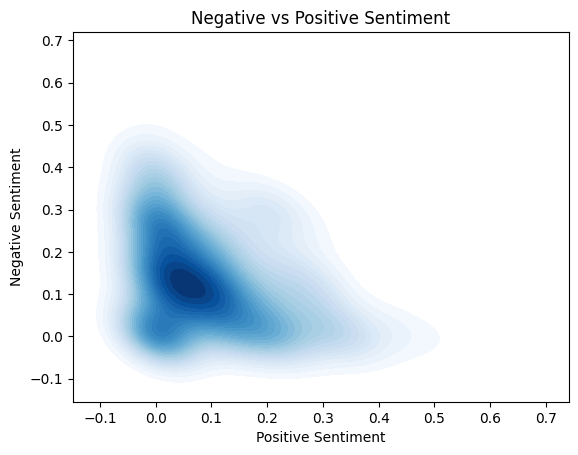

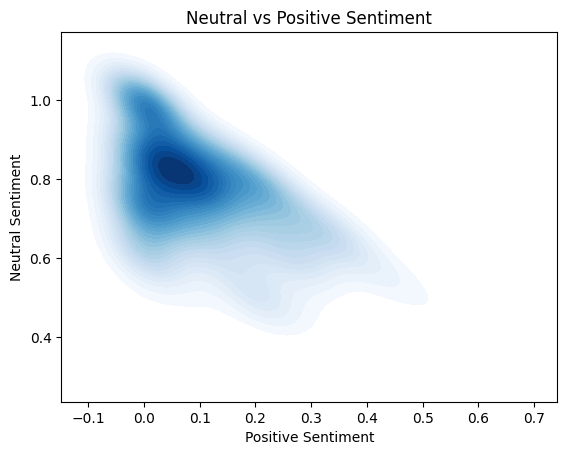

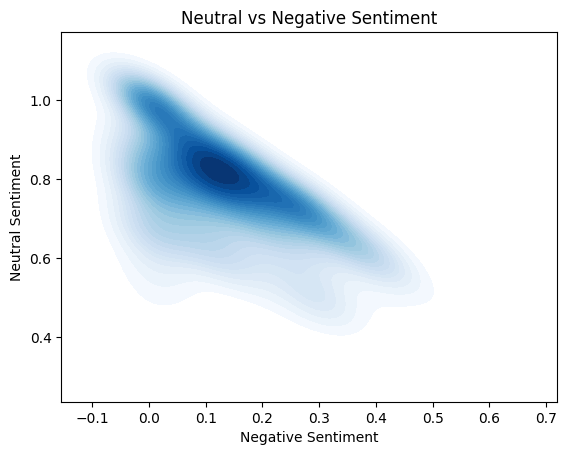

In [43]:
ax = sns.kdeplot(x='sentiment_pos',y='sentiment_neg', data=reviews_df, fill=True, cmap = 'Blues', levels = 30)
ax.set_xlabel('Positive Sentiment')
ax.set_ylabel('Negative Sentiment')
ax.set_title('Negative vs Positive Sentiment')
plt.show()

ax = sns.kdeplot(x='sentiment_pos',y='sentiment_neu', data=reviews_df, fill=True, cmap = 'Blues', levels = 30)
ax.set_xlabel('Positive Sentiment')
ax.set_ylabel('Neutral Sentiment')
ax.set_title('Neutral vs Positive Sentiment')
plt.show()


ax = sns.kdeplot(x='sentiment_neg',y='sentiment_neu', data=reviews_df, fill=True, cmap = 'Blues', levels = 30)
ax.set_xlabel('Negative Sentiment')
ax.set_ylabel('Neutral Sentiment')
ax.set_title('Neutral vs Negative Sentiment')
plt.show()

In [44]:
# Create dataframe to analyze relationship between review ratings and sentiment.
sentiment_and_ratings_df = reviews_df[['snippet', 'rating', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos', 'sentiment_compound']].copy()
sentiment_and_ratings_df.head(5)

,snippet,rating,sentiment_neg,sentiment_neu,sentiment_pos,sentiment_compound
0,Easy drop and hook. Never had a problem with s...,5.0,0.050,0.637,0.314,0.8809
1,You make living across from you hell. Constant...,1.0,0.056,0.944,0.000,-0.6124
2,Trucker beware... Mostly everyone is helpful e...,1.0,0.091,0.779,0.130,0.6181
3,Lady night check in very rude I been completel...,1.0,0.249,0.600,0.151,-0.6597
4,All the security at the factory are kind and e...,1.0,0.000,0.775,0.225,0.8271


In [45]:
sentiment_and_ratings_df.describe()

,rating,sentiment_neg,sentiment_neu,sentiment_pos,sentiment_compound
count,198.000000,198.000000,198.000000,198.000000,198.000000
mean,2.080808,0.137348,0.755167,0.107500,-0.116042
std,1.600614,0.124302,0.137915,0.119406,0.582955
min,1.000000,0.000000,0.407000,0.000000,-0.966300
25%,1.000000,0.000000,0.658000,0.000000,-0.612400
50%,1.000000,0.114000,0.758500,0.074000,-0.150150
75%,3.000000,0.218750,0.841750,0.184500,0.440400
max,5.000000,0.565000,1.000000,0.593000,0.981900


These results reveal an evident relationship between customer ratings and sentiment scores. Lower ratings are associated with more negative sentiment and higher ratings align with more positive sentiment. The average rating is relatively low at 2.08 out of 5, which corresponds with the negative mean compound sentiment score (-0.116).



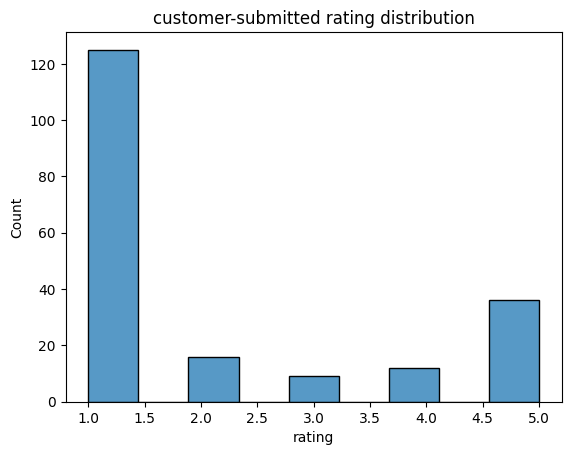

In [46]:
ax = sns.histplot(sentiment_and_ratings_df['rating'])
ax.set_title('customer-submitted rating distribution')
plt.show()